# Road Accident Analysis — 01 Exploratory Data Analysis

An **EDA / visualization** project: UK road collisions in 2021 — **101,087 records** from the DfT with severity, vehicles, casualties, timing, speed limit, and road/weather conditions. This notebook covers the data overview — shape, types, missing values, numerical distributions, and human-readable categorical distributions framing the deeper analysis in notebook 02.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df = utils.load_data()
df_mapped = utils.add_mapped_labels(df)
print('Shape of dataset:', df.shape)
df_mapped.head()

Shape of dataset: (101087, 15)


,collision_index,date,day_of_week,time,collision_severity,number_of_vehicles,number_of_casualties,speed_limit,light_conditions,weather_conditions,...,road_type,longitude,latitude,severity_label,area_label,road_type_label,weather_label,light_label,road_surface_label,day_name
0,2021170H10581,07/07/2021,4,12:30,3,2,1,30,1,1,...,6,-1.215535,54.705385,Slight,Urban,Single carriageway,Fine no high winds,Daylight,Dry,Wednesday
1,2021170M10181,26/02/2021,6,19:30,2,1,1,30,4,1,...,6,-1.246477,54.565540,Serious,Urban,Single carriageway,Fine no high winds,Darkness - lights lit,Dry,Friday
2,2021170M30721,20/05/2021,5,16:45,3,2,1,40,1,2,...,1,-1.212540,54.521556,Slight,Urban,Roundabout,Raining no high winds,Daylight,Wet or damp,Thursday
3,2021170L50121,30/01/2021,7,18:08,2,1,1,30,4,1,...,6,-0.894618,54.555397,Serious,Rural,Single carriageway,Fine no high winds,Darkness - lights lit,Dry,Saturday
4,2021111130730,19/10/2021,3,19:44,3,2,2,30,4,2,...,6,-1.549932,54.529984,Slight,Urban,Single carriageway,Raining no high winds,Darkness - lights lit,Wet or damp,Tuesday


## 1. Structure & Data Types

In [2]:
print("Data Type Distribution:", df.dtypes.value_counts().to_dict())
df.info()

Data Type Distribution: {dtype('int64'): 10, <StringDtype(na_value=nan)>: 3, dtype('float64'): 2}
<class 'pandas.DataFrame'>
RangeIndex: 101087 entries, 0 to 101086
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   collision_index          101087 non-null  str    
 1   date                     101087 non-null  str    
 2   day_of_week              101087 non-null  int64  
 3   time                     101087 non-null  str    
 4   collision_severity       101087 non-null  int64  
 5   number_of_vehicles       101087 non-null  int64  
 6   number_of_casualties     101087 non-null  int64  
 7   speed_limit              101087 non-null  int64  
 8   light_conditions         101087 non-null  int64  
 9   weather_conditions       101087 non-null  int64  
 10  road_surface_conditions  101087 non-null  int64  
 11  urban_or_rural_area      101087 non-null  int64  
 12  road_type                10

## 2. Missing Values

In [3]:
mr = utils.missing_report(df)
print('Columns with missing values:', len(mr))
print(mr.to_string())

Columns with missing values: 2
           missing   pct
longitude       17  0.02
latitude        17  0.02


## 3. Numeric Distributions

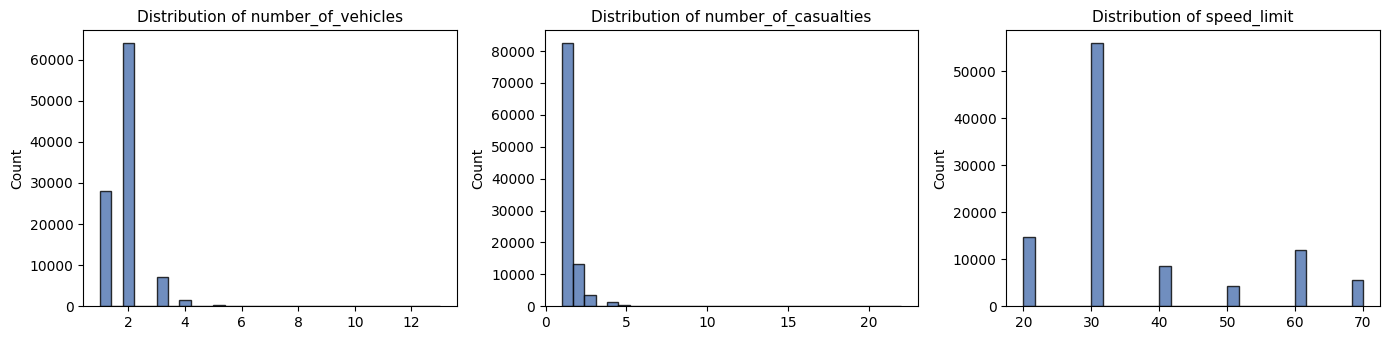

,number_of_vehicles,number_of_casualties,speed_limit
count,101087.00,101087.00,101087.00
mean,1.84,1.27,36.00
std,0.68,0.67,14.12
min,1.00,1.00,20.00
25%,1.00,1.00,30.00
50%,2.00,1.00,30.00
75%,2.00,1.00,40.00
max,13.00,22.00,70.00


In [4]:
num_cols = ['number_of_vehicles', 'number_of_casualties', 'speed_limit']
fig, ax = plt.subplots(1, len(num_cols), figsize=(14, 3.5))
for a, col in zip(ax, num_cols):
    a.hist(df[col].dropna(), bins=30, color='#4c72b0', edgecolor='black', alpha=0.8)
    a.set_title(f'Distribution of {col}', fontsize=11)
    a.set_ylabel('Count')
plt.tight_layout()
plt.show()

display(df[num_cols].describe().round(2))

## 4. Categorical Distributions (Mapped Labels)

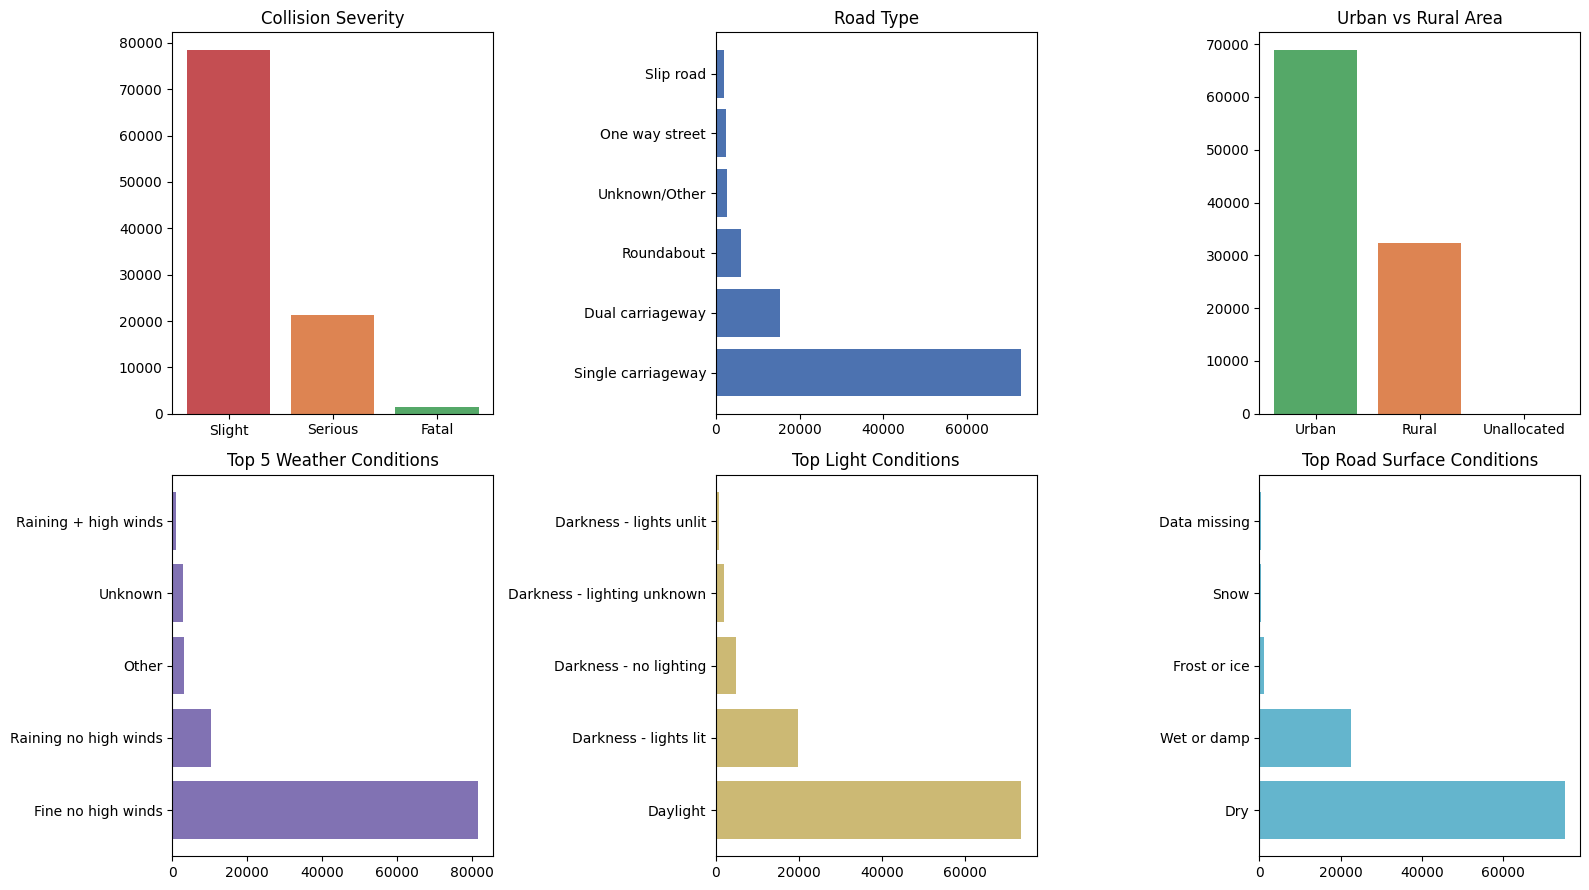

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Severity
sc = df_mapped['severity_label'].value_counts()
axes[0, 0].bar(sc.index, sc.values, color=['#c44e52', '#dd8452', '#55a868'])
axes[0, 0].set_title('Collision Severity')

# Road Type
rt = df_mapped['road_type_label'].value_counts()
axes[0, 1].barh(rt.index, rt.values, color='#4c72b0')
axes[0, 1].set_title('Road Type')

# Urban vs Rural
ur = df_mapped['area_label'].value_counts()
axes[0, 2].bar(ur.index, ur.values, color=['#55a868', '#dd8452', '#c44e52'])
axes[0, 2].set_title('Urban vs Rural Area')

# Weather Conditions
wc = df_mapped['weather_label'].value_counts().head(5)
axes[1, 0].barh(wc.index, wc.values, color='#8172b3')
axes[1, 0].set_title('Top 5 Weather Conditions')

# Light Conditions
lc = df_mapped['light_label'].value_counts().head(5)
axes[1, 1].barh(lc.index, lc.values, color='#ccb974')
axes[1, 1].set_title('Top Light Conditions')

# Road Surface Conditions
rs = df_mapped['road_surface_label'].value_counts().head(5)
axes[1, 2].barh(rs.index, rs.values, color='#64b5cd')
axes[1, 2].set_title('Top Road Surface Conditions')

plt.tight_layout()
plt.show()

## 5. Summary

### Data Analysis Key Findings
- **High Completeness**: Out of 101,087 records, only 17 rows (~0.02%) have missing values (limited to `longitude` & `latitude`).
- **Vehicle & Casualty Footprint**: The typical collision involves **1.84 vehicles** (median: 2) and **1.27 casualties** (median: 1). Max vehicles involved in a multi-car pileup was 13, and max casualties was 22.
- **Road Type Dominance**: **Single carriageways** account for the vast majority of collisions (~73,054 crashes, ~72.3%), followed by dual carriageways (~15,299 crashes, ~15.1%).
- **Urban Concentration**: **~68% of all collisions** occur in urban areas, driven by higher junction and traffic volume density.

### Insights or Next Steps
- Proceed to **Notebook 02 — Analysis** to examine cross-variable relationships: peak collision timing, speed limit lethality thresholds, and statistical significance tests across environmental risk factors.